## Import Required Libraries

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

## Loading Dataset

In [95]:
df = pd.read_csv(r'D:\My Course Ai Bin\Machine Learning\Linear\housing[1].csv')
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


## EDA

In [96]:
df.shape 

(20640, 10)

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [98]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [99]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [100]:
df.columns  

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

## Handle Missing Values

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

imputer = SimpleImputer(strategy='mean')
df[num_cols] = imputer.fit_transform(df[num_cols])

print(df.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


## Converting Categorical Columns 

In [102]:
categorical_cols = df.select_dtypes(include='object').columns
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


## Correlation heatmap


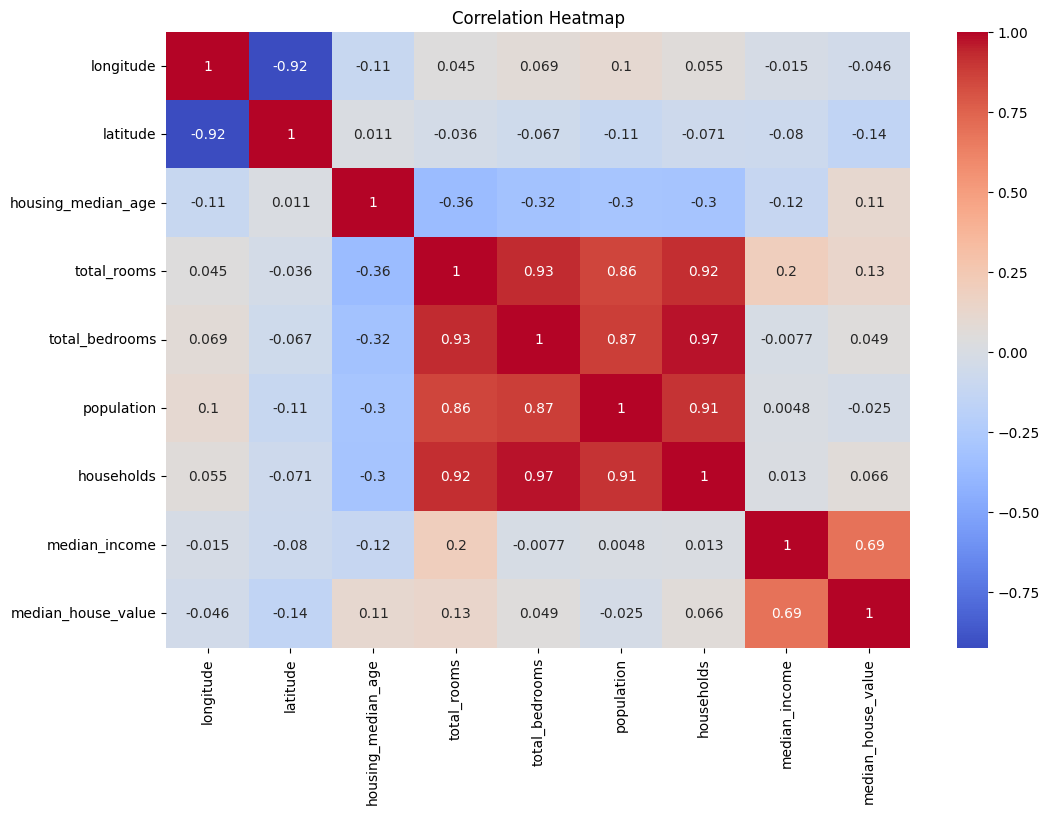

In [103]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Distribution graph of house prices


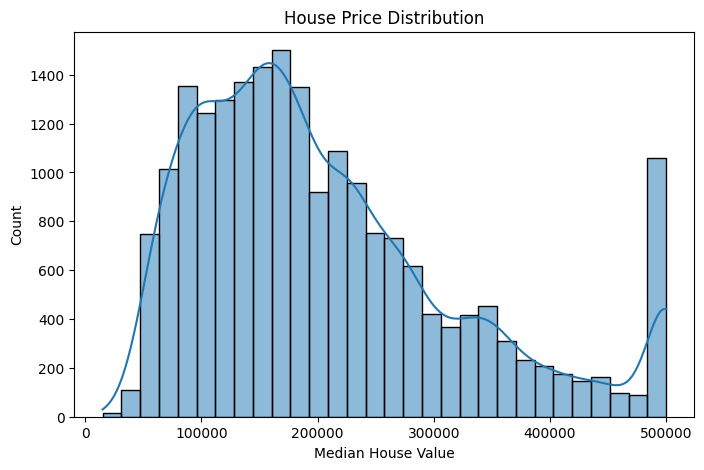

In [104]:
plt.figure(figsize=(8,5))
sns.histplot(
    df['median_house_value'],
    bins=30,
    kde=True
)
plt.title('House Price Distribution')
plt.xlabel('Median House Value')
plt.ylabel('Count')
plt.show()

## Median income vs house value


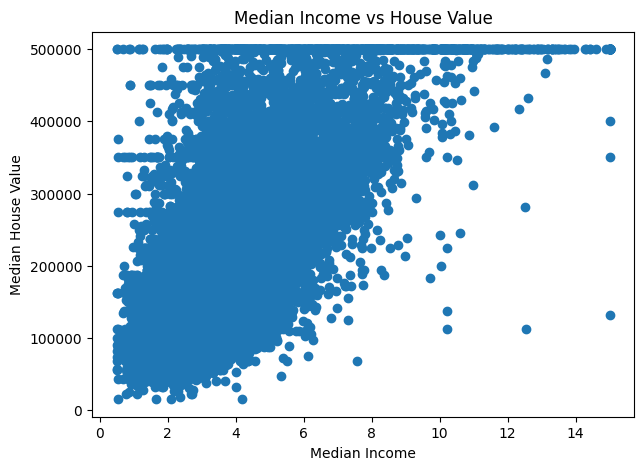

In [105]:
plt.figure(figsize=(7,5))
plt.scatter(
    df['median_income'],
    df['median_house_value']
)
plt.title('Median Income vs House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()

## Features and Target

In [106]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']
print('Features Shape:', X.shape)
print('Target Shape:', y.shape)

Features Shape: (20640, 12)
Target Shape: (20640,)


## Splitting Dataset

In [107]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print('Training Data Shape:', X_train.shape)
print('Testing Data Shape:', X_test.shape)

Training Data Shape: (16512, 12)
Testing Data Shape: (4128, 12)


## Train Linear Regression Model

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
print('Model Training Completed')

Model Training Completed


## Making Predictions

In [109]:
y_pred = model.predict(X_test)

prediction_df = pd.DataFrame({
    'Actual Values': y_test,
    'Predicted Values': y_pred
})
prediction_df.head()

,Actual Values,Predicted Values
20046,47700.0,64629.450798
3024,45800.0,134799.340836
15663,500001.0,266063.381391
20484,218600.0,278576.433468
9814,278000.0,273343.436715


## Evaluating the Model 

In [110]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R2 Score:', r2)

Mean Absolute Error: 50701.77903133022
Mean Squared Error: 4904399775.949299
R2 Score: 0.6257351821159687


## Actual vs Predicted Graph 

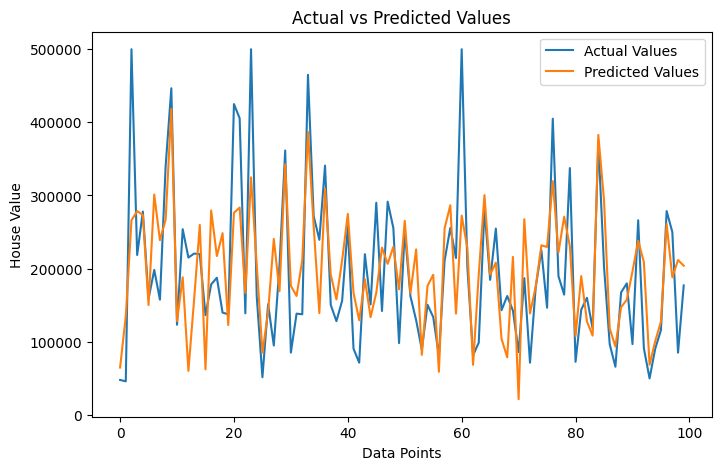

In [111]:
plt.figure(figsize=(8,5))
plt.plot(y_test.values[:100], label='Actual Values')
plt.plot(y_pred[:100], label='Predicted Values')
plt.title('Actual vs Predicted Values')
plt.xlabel('Data Points')
plt.ylabel('House Value')
plt.legend()
plt.show()

## Feature Importance 

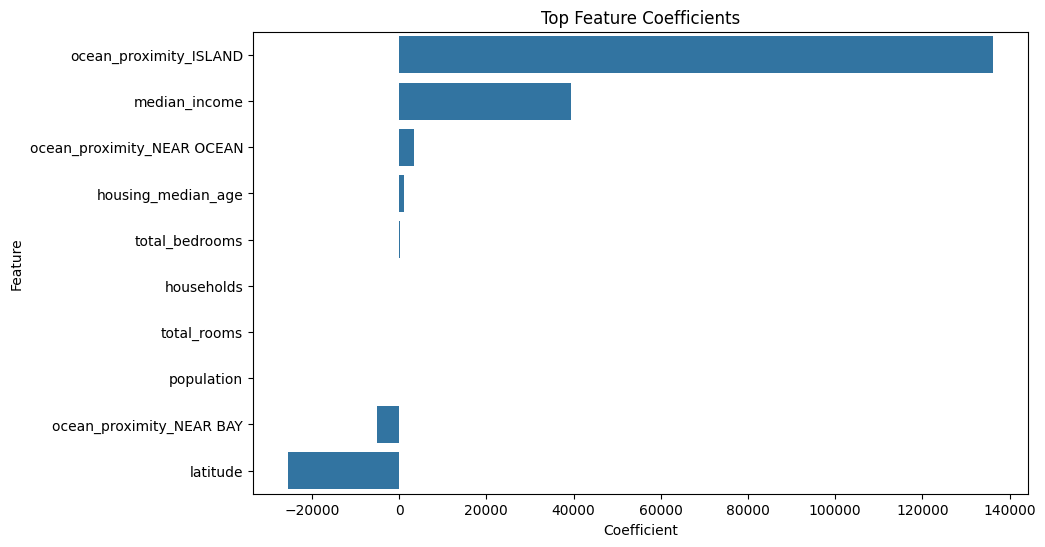

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)
plt.figure(figsize=(10,6))
sns.barplot(
    x='Coefficient',
    y='Feature',
    data=importance.head(10)
)
plt.title('Top Feature Coefficients')
plt.show()

## Sample Prediction 

In [113]:
sample_data = X.iloc[[10]]
prediction = model.predict(sample_data)
print('Predicted House Value:', prediction[0])

Predicted House Value: 236350.37164362986
